# Student Performance Prediction; Linear Regression

## Objective

The objective of this experiment is to predict a student's final examination
marks using academic, behavioral, demographic, and support-related features.

Linear Regression is used as the primary regression algorithm.

Two models are evaluated:

1. Baseline Linear Regression using the original predictive features.
2. Enhanced Linear Regression incorporating the engineered
   `AttendanceStudyInteraction` feature.

Model performance is evaluated using MAE, RMSE, and R², with 5-fold
cross-validation used to assess generalization.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.endswith(".csv"):
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/redheadcoffee/student-performance-feature-engineered-v2/student_performance_feature_engineered_v2.csv


In [3]:
DATA_PATH = "/kaggle/input/datasets/redheadcoffee/student-performance-feature-engineered-v2/student_performance_feature_engineered_v2.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2000, 16)


,StudentID,Name,Age,Gender,AttendancePct,StudyHoursPerWeek,PreviousGrade,AssignmentMarks,InternalAssessmentMarks,OnlineClasses,ExtracurricularActivities,ParentalSupport,FinalExamMarks,ContinuousAssessmentAverage,PerformanceTrend,AttendanceStudyInteraction
0,STU10001,Allison Hill,23,Male,88.60,7.78,85.35,53.76,67.11,Yes,1,Medium,68.20,60.435,-24.915,689.3080
1,STU10002,Noah Rhodes,20,Female,84.17,20.28,65.60,59.41,52.96,Yes,0,Low,52.83,56.185,-9.415,1706.9676
2,STU10003,Angie Henderson,21,Female,84.84,18.51,62.42,62.05,59.86,No,2,Medium,65.05,60.955,-1.465,1570.3884
3,STU10004,Daniel Wagner,23,Female,64.34,9.96,62.85,54.59,49.67,No,1,Medium,48.23,52.130,-10.720,640.8264
4,STU10005,Cristian Santos,19,Female,90.12,22.43,62.21,76.58,70.07,No,0,Medium,68.26,73.325,11.115,2021.3916


DATA VALIDATION


In [4]:
print("Shape:", df.shape)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget statistics:")
display(df["FinalExamMarks"].describe())

Shape: (2000, 16)

Missing values:


StudentID                      0
Name                           0
Age                            0
Gender                         0
AttendancePct                  0
StudyHoursPerWeek              0
PreviousGrade                  0
AssignmentMarks                0
InternalAssessmentMarks        0
OnlineClasses                  0
ExtracurricularActivities      0
ParentalSupport                0
FinalExamMarks                 0
ContinuousAssessmentAverage    0
PerformanceTrend               0
AttendanceStudyInteraction     0
dtype: int64


Duplicate rows:
0

Target statistics:


count    2000.000000
mean       61.987645
std         9.611301
min        31.390000
25%        55.537500
50%        62.130000
75%        68.487500
max        92.840000
Name: FinalExamMarks, dtype: float64

=========================================================
 DEFINE TARGET
 

In [5]:
target = "FinalExamMarks"

y = df[target].copy()

print("Target:", target)
print("Target shape:", y.shape)

Target: FinalExamMarks
Target shape: (2000,)


# Define Baseline features

In [6]:
baseline_features = [
    "Age",
    "Gender",
    "AttendancePct",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "AssignmentMarks",
    "InternalAssessmentMarks",
    "OnlineClasses",
    "ExtracurricularActivities",
    "ParentalSupport"
]

X_baseline = df[baseline_features].copy()

print("Baseline feature matrix:", X_baseline.shape)
display(X_baseline.head())

Baseline feature matrix: (2000, 10)


,Age,Gender,AttendancePct,StudyHoursPerWeek,PreviousGrade,AssignmentMarks,InternalAssessmentMarks,OnlineClasses,ExtracurricularActivities,ParentalSupport
0,23,Male,88.60,7.78,85.35,53.76,67.11,Yes,1,Medium
1,20,Female,84.17,20.28,65.60,59.41,52.96,Yes,0,Low
2,21,Female,84.84,18.51,62.42,62.05,59.86,No,2,Medium
3,23,Female,64.34,9.96,62.85,54.59,49.67,No,1,Medium
4,19,Female,90.12,22.43,62.21,76.58,70.07,No,0,Medium


# train/test split

In [7]:
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train_base.shape[0])
print("Testing samples :", X_test_base.shape[0])

Training samples: 1600
Testing samples : 400


# PREPROCESSING PIPELINE

In [8]:
numeric_features = [
    "Age",
    "AttendancePct",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "AssignmentMarks",
    "InternalAssessmentMarks",
    "ExtracurricularActivities"
]

categorical_features = [
    "Gender",
    "OnlineClasses",
    "ParentalSupport"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# BASELINE LINEAR REGRESSION

In [9]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

baseline_model.fit(
    X_train_base,
    y_train
)

print("Baseline Linear Regression trained successfully.")

Baseline Linear Regression trained successfully.


#  BASELINE PREDICTIONS

In [10]:
y_pred_base = baseline_model.predict(
    X_test_base
)

print("First 10 predictions:")
display(
    pd.DataFrame({
        "Actual": y_test.iloc[:10].values,
        "Predicted": y_pred_base[:10]
    })
)

First 10 predictions:


,Actual,Predicted
0,64.24,63.815271
1,62.22,68.737150
2,68.53,69.322554
3,64.52,65.195289
4,52.41,59.760627
5,58.76,58.384994
6,56.79,58.080923
7,61.08,63.009874
8,51.36,60.732995
9,82.66,79.844241


# BASELINE MODEL EVALUATION

In [11]:
mae_base = mean_absolute_error(
    y_test,
    y_pred_base
)

rmse_base = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_base
    )
)

r2_base = r2_score(
    y_test,
    y_pred_base
)

print("Baseline Linear Regression")
print("-" * 35)
print(f"MAE  : {mae_base:.4f}")
print(f"RMSE : {rmse_base:.4f}")
print(f"R²   : {r2_base:.4f}")

Baseline Linear Regression
-----------------------------------
MAE  : 4.8837
RMSE : 6.1778
R²   : 0.5955


# ACTUAL VS PREDICTED

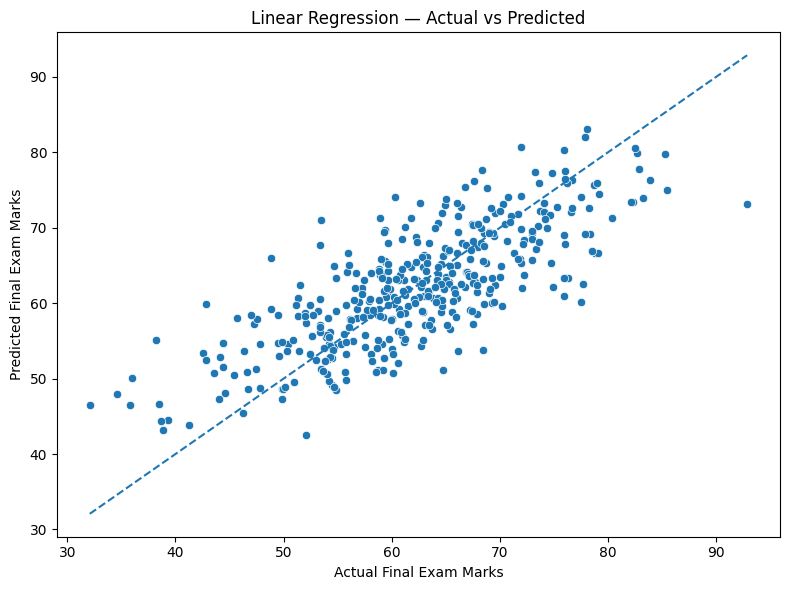

In [12]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_base
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Final Exam Marks")
plt.ylabel("Predicted Final Exam Marks")
plt.title("Linear Regression — Actual vs Predicted")

plt.tight_layout()
plt.show()

# RESIDUAL ANALYSIS

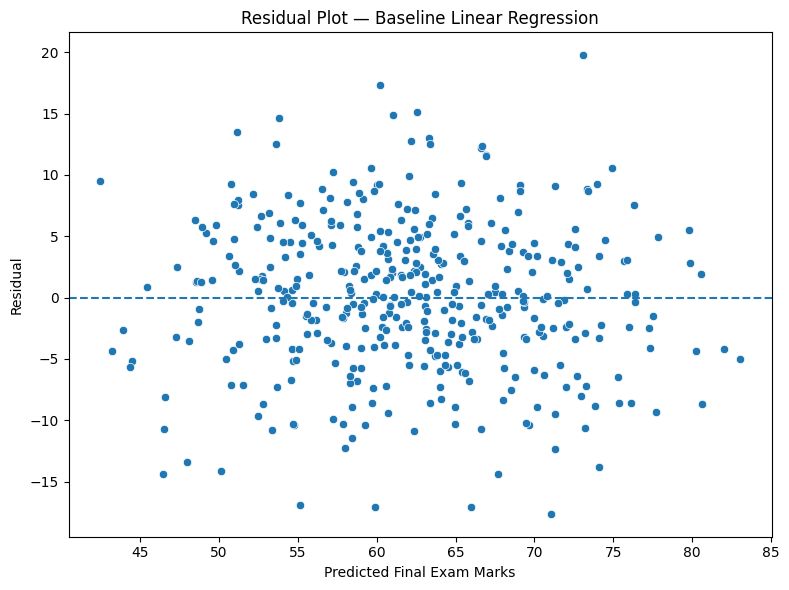

In [13]:
residuals_base = y_test - y_pred_base

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_pred_base,
    y=residuals_base
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Final Exam Marks")
plt.ylabel("Residual")
plt.title("Residual Plot — Baseline Linear Regression")

plt.tight_layout()
plt.show()


# 5-FOLD CROSS-VALIDATION



In [14]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_base = cross_validate(
    baseline_model,
    X_baseline,
    y,
    cv=kf,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=False
)

cv_summary_base = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": -cv_results_base["test_MAE"],
    "RMSE": -cv_results_base["test_RMSE"],
    "R2": cv_results_base["test_R2"]
})

display(cv_summary_base)

print("\nMean CV performance:")
print(f"MAE  : {cv_summary_base['MAE'].mean():.4f}")
print(f"RMSE : {cv_summary_base['RMSE'].mean():.4f}")
print(f"R²   : {cv_summary_base['R2'].mean():.4f}")

,Fold,MAE,RMSE,R2
0,1,4.883723,6.177838,0.595453
1,2,4.854217,6.047251,0.659515
2,3,4.885225,6.109995,0.590645
3,4,4.950749,6.132125,0.531401
4,5,4.718127,6.035975,0.580545



Mean CV performance:
MAE  : 4.8584
RMSE : 6.1006
R²   : 0.5915


# Model B — Add engineered interaction feature
# =========================================================

In [15]:
enhanced_features = baseline_features + [
    "AttendanceStudyInteraction"
]

X_enhanced = df[enhanced_features].copy()

print("Enhanced feature matrix:", X_enhanced.shape)

Enhanced feature matrix: (2000, 11)


# SPLIT ENHANCED TRAIN / TEST SPLIT

In [16]:
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced,
    y,
    test_size=0.20,
    random_state=42
)

# ENHANCED PREPROCESSING

In [17]:
enhanced_numeric_features = numeric_features + [
    "AttendanceStudyInteraction"
]

enhanced_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        enhanced_numeric_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

# ENHANCED LINEAR REGRESSION

In [18]:
enhanced_model = Pipeline([
    ("preprocessor", enhanced_preprocessor),
    ("regressor", LinearRegression())
])

enhanced_model.fit(
    X_train_enh,
    y_train_enh
)

y_pred_enh = enhanced_model.predict(
    X_test_enh
)

print("Enhanced Linear Regression trained successfully.")

Enhanced Linear Regression trained successfully.


# ENHANCED MODEL EVALUATION

In [19]:
mae_enh = mean_absolute_error(
    y_test_enh,
    y_pred_enh
)

rmse_enh = np.sqrt(
    mean_squared_error(
        y_test_enh,
        y_pred_enh
    )
)

r2_enh = r2_score(
    y_test_enh,
    y_pred_enh
)

print("Enhanced Linear Regression")
print("-" * 35)
print(f"MAE  : {mae_enh:.4f}")
print(f"RMSE : {rmse_enh:.4f}")
print(f"R²   : {r2_enh:.4f}")

Enhanced Linear Regression
-----------------------------------
MAE  : 4.8843
RMSE : 6.1797
R²   : 0.5952


# Compare the two models

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Enhanced Linear Regression"
    ],
    "MAE": [
        mae_base,
        mae_enh
    ],
    "RMSE": [
        rmse_base,
        rmse_enh
    ],
    "R2": [
        r2_base,
        r2_enh
    ]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Baseline Linear Regression,4.883723,6.177838,0.595453
1,Enhanced Linear Regression,4.884350,6.179683,0.595211


# Cross-validation for enhanced model

In [21]:
# ============================================================
# 21. ENHANCED MODEL CROSS-VALIDATION
# ============================================================

cv_results_enh = cross_validate(
    enhanced_model,
    X_enhanced,
    y,
    cv=kf,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=False
)

cv_summary_enh = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": -cv_results_enh["test_MAE"],
    "RMSE": -cv_results_enh["test_RMSE"],
    "R2": cv_results_enh["test_R2"]
})

display(cv_summary_enh)

print("\nMean CV performance:")
print(f"MAE  : {cv_summary_enh['MAE'].mean():.4f}")
print(f"RMSE : {cv_summary_enh['RMSE'].mean():.4f}")
print(f"R²   : {cv_summary_enh['R2'].mean():.4f}")

,Fold,MAE,RMSE,R2
0,1,4.884350,6.179683,0.595211
1,2,4.849173,6.043902,0.659892
2,3,4.885344,6.110638,0.590559
3,4,4.961652,6.144122,0.529566
4,5,4.738497,6.047327,0.578966



Mean CV performance:
MAE  : 4.8638
RMSE : 6.1051
R²   : 0.5908


# Feature importance using permutation importance

In [22]:
perm = permutation_importance(
    enhanced_model,
    X_test_enh,
    y_test_enh,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": X_enhanced.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_STD": perm.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
)

display(importance_df)

,Feature,Importance_Mean,Importance_STD
6,InternalAssessmentMarks,0.128808,0.016482
5,AssignmentMarks,0.100527,0.009945
4,PreviousGrade,0.062549,0.011842
2,AttendancePct,0.039169,0.010641
9,ParentalSupport,0.034310,0.005527
7,OnlineClasses,0.010874,0.002099
3,StudyHoursPerWeek,0.008035,0.003304
1,Gender,0.003330,0.002086
8,ExtracurricularActivities,0.001791,0.001456
0,Age,0.000095,0.000945


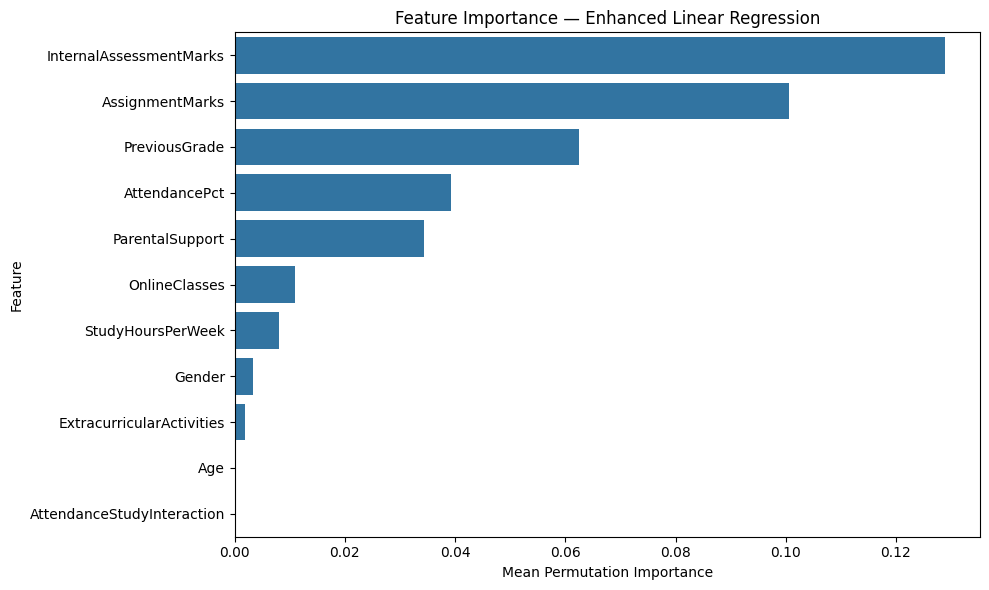

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance_Mean",
    y="Feature"
)

plt.xlabel("Mean Permutation Importance")
plt.ylabel("Feature")
plt.title("Feature Importance — Enhanced Linear Regression")

plt.tight_layout()
plt.show()

# Final prediction sample

In [24]:
sample_student = X_test_enh.iloc[[0]]

actual_mark = y_test_enh.iloc[0]

predicted_mark = enhanced_model.predict(
    sample_student
)[0]

print("Student features:")
display(sample_student)

print(f"Actual Final Exam Marks    : {actual_mark:.2f}")
print(f"Predicted Final Exam Marks : {predicted_mark:.2f}")
print(f"Absolute Error             : {abs(actual_mark - predicted_mark):.2f}")

Student features:


,Age,Gender,AttendancePct,StudyHoursPerWeek,PreviousGrade,AssignmentMarks,InternalAssessmentMarks,OnlineClasses,ExtracurricularActivities,ParentalSupport,AttendanceStudyInteraction
1860,22,Female,75.44,25.9,77.67,71.71,60.44,No,1,Medium,1953.896


Actual Final Exam Marks    : 64.24
Predicted Final Exam Marks : 63.81
Absolute Error             : 0.43


# SAVE FINAL MODEL

In [25]:
MODEL_PATH = "/kaggle/working/linear_regression_final.joblib"

joblib.dump(
    enhanced_model,
    MODEL_PATH
)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
/kaggle/working/linear_regression_final.joblib


In [26]:
RESULT_PATH = "/kaggle/working/linear_regression_results.csv"

comparison.to_csv(
    RESULT_PATH,
    index=False
)

print("Results saved successfully:")
print(RESULT_PATH)

Results saved successfully:
/kaggle/working/linear_regression_results.csv
